In [9]:
import csv
import os

import torch
import torch.nn as nn 
import torchvision.models as models

from PIL import Image
from torch.utils import data
from torchvision import transforms as T

from tqdm import tqdm

In [10]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

# DataLoader

In [4]:
class mavDataLoader(data.Dataset):
    
    # Квантерион -> матрица поворота
    @staticmethod
    def quat_to_rotmat(q):
        """
        q: (..., 4)  quaternion [qw, qx, qy, qz]
        return: (..., 3, 3) rotation matrix
        """
        qw, qx, qy, qz = q.unbind(-1)

        R = torch.stack([
            1 - 2*(qy*qy + qz*qz),  2*(qx*qy - qz*qw),      2*(qx*qz + qy*qw),
            2*(qx*qy + qz*qw),      1 - 2*(qx*qx + qz*qz),  2*(qy*qz - qx*qw),
            2*(qx*qz - qy*qw),      2*(qy*qz + qx*qw),      1 - 2*(qx*qx + qy*qy)
        ], dim=-1)

        return R.reshape(q.shape[:-1] + (3, 3))
    
    # Матрица поврота -> axis-angle
    @staticmethod
    def rotmat_to_rotvec(R):
        """
        R: (..., 3, 3)
        return: (..., 3) axis-angle
        """
        trace = R[..., 0, 0] + R[..., 1, 1] + R[..., 2, 2]
        cos_theta = (trace - 1) / 2
        cos_theta = torch.clamp(cos_theta, -1.0, 1.0)

        theta = torch.acos(cos_theta)

        rx = R[..., 2, 1] - R[..., 1, 2]
        ry = R[..., 0, 2] - R[..., 2, 0]
        rz = R[..., 1, 0] - R[..., 0, 1]

        r = torch.stack([rx, ry, rz], dim=-1)

        sin_theta = torch.sin(theta)
        mask = sin_theta.abs() > 1e-6

        rotvec = torch.zeros_like(r)
        rotvec[mask] = r[mask] * (theta[mask] / (2 * sin_theta[mask]))[..., None]

        return rotvec

    # Ф-ия дельты
    def compute_delta_torch(self, p_t, q_t, p_t1, q_t1):
        """
        p_t, p_t1 : (3,)
        q_t, q_t1 : (4,)  [qw, qx, qy, qz]

        return:
            delta_t : (3,)
            delta_r : (3,) axis-angle
        """

        R_t = self.quat_to_rotmat(q_t)
        R_t1 = self.quat_to_rotmat(q_t1)

        # ΔR = R_t^T R_{t+1}
        delta_R = R_t.transpose(-1, -2) @ R_t1

        # Δt = R_t^T (p_{t+1} - p_t)
        delta_t = R_t.transpose(-1, -2) @ (p_t1 - p_t)

        # rotation matrix → axis-angle
        delta_r = self.rotmat_to_rotvec(delta_R)

        return delta_t, delta_r

    
    def __init__(self, path, transform=None):
        self.transform = transform
        self.path = path
        
        # Блок обработки координат
        with open(os.path.join(self.path, 'state_groundtruth_estimate0/data.csv'), 'r', encoding='utf-8') as f: # Вытаскиваю словарь таймстемпов с координатами
            self.dct_of_timestamp_with_coord = {int(dct['#timestamp']): [float(dct[' p_RS_R_x [m]']), float(dct[' p_RS_R_y [m]']), float(dct[' p_RS_R_z [m]']),
                                                float(dct[' q_RS_w []']), float(dct[' q_RS_x []']), float(dct[' q_RS_y []']), float(dct[' q_RS_z []'])] for dct in csv.DictReader(f)}
        
        # Блок обработки камеры 0
        with open(os.path.join(self.path, 'cam0/data.csv'), 'r', encoding='utf-8') as f: # Вытаскиваю словарь камеры 1
            self.dct_of_timestamp_cam0 = {int(dct['#timestamp [ns]']): dct['filename'] for dct in csv.DictReader(f)}
        # Блок обработки камеры 1
        with open(os.path.join(self.path, 'cam1/data.csv'), 'r', encoding='utf-8') as f: # Вытаскиваю словарь камеры 1
            self.dct_of_timestamp_cam1 = {int(dct['#timestamp [ns]']): dct['filename'] for dct in csv.DictReader(f)}
        
        # Создаем последовательные во времени пары кадров
        frames = sorted(self.dct_of_timestamp_with_coord.keys())
        self.pair = list(zip(frames[:-1], frames[1:]))
        
        self.length = len(self.pair)
        
    def __getitem__(self, item):
        timestamp_1, timestamp_2 = self.pair[item]
        
        # Получаем изображения с первой камеры
        func_of_key = lambda x, y: x if x in y else min(y, key=lambda k: (abs(k - x), k))
        key1, key2 = func_of_key(timestamp_1, self.dct_of_timestamp_cam0.keys()), func_of_key(timestamp_2, self.dct_of_timestamp_cam0.keys())
        path_to_img1, path_to_img2 = os.path.join(self.path, f'cam0/data/{self.dct_of_timestamp_cam0[key1]}'), os.path.join(self.path, f'cam0/data/{self.dct_of_timestamp_cam0[key2]}')
        img1, img2 = Image.open(path_to_img1).convert('RGB'), Image.open(path_to_img2).convert('RGB')
        x = None
        if self.transform:
            img1, img2 = self.transform(img1), self.transform(img2)
            x = torch.concat((img1, img2))
        
        # Получаем координаты
        coord1, coord2 = self.dct_of_timestamp_with_coord[timestamp_1], self.dct_of_timestamp_with_coord[timestamp_2]
        p_coord1, q_coord1, p_coord2, q_coord2 = torch.tensor(coord1[:3]), torch.tensor(coord1[3:]), torch.tensor(coord2[:3]), torch.tensor(coord2[3:])
        p_t, q_t = self.compute_delta_torch(p_coord1, q_coord1, p_coord2, q_coord2)
        
        
        y = torch.cat((p_t, q_t), dim=0)
        
        return x, y
    
    def __len__(self):
        return self.length


In [11]:

transform = T.Compose([
    T.ToTensor()
])
dataset = mavDataLoader('mav0', transform)
dtrain, dtest = data.random_split(dataset, [0.7, 0.3])
train_data = data.DataLoader(dtrain, batch_size=16, shuffle=True, drop_last=True)
test_data = data.DataLoader(dtest, batch_size=16)

## Метрики

In [14]:
def step_translation_error(pred, gt):  # Ошибка трансляции
    """
    pred, gt: (B, 6)
    """
    pred_t = pred[:, :3]
    gt_t = gt[:, :3]
    return torch.norm(pred_t - gt_t, dim=1)  # (B,)

def rotvec_to_rotmat(r):
    """
    r: (N, 3) axis-angle (rad)
    return: (N, 3, 3)
    """
    theta = torch.norm(r, dim=1, keepdim=True)  # (N,1)
    axis = r / (theta + 1e-8)

    cos = torch.cos(theta)
    sin = torch.sin(theta)

    x, y, z = axis[:, 0], axis[:, 1], axis[:, 2]

    R = torch.zeros((r.shape[0], 3, 3), device=r.device)

    R[:, 0, 0] = cos[:, 0] + x*x*(1-cos[:, 0])
    R[:, 1, 1] = cos[:, 0] + y*y*(1-cos[:, 0])
    R[:, 2, 2] = cos[:, 0] + z*z*(1-cos[:, 0])

    R[:, 0, 1] = x*y*(1-cos[:, 0]) - z*sin[:, 0]
    R[:, 0, 2] = x*z*(1-cos[:, 0]) + y*sin[:, 0]
    R[:, 1, 0] = y*x*(1-cos[:, 0]) + z*sin[:, 0]
    R[:, 1, 2] = y*z*(1-cos[:, 0]) - x*sin[:, 0]
    R[:, 2, 0] = z*x*(1-cos[:, 0]) - y*sin[:, 0]
    R[:, 2, 1] = z*y*(1-cos[:, 0]) + x*sin[:, 0]

    return R

def step_rotation_error(pred, gt):
    pred_r = pred[:, 3:]
    gt_r = gt[:, 3:]

    R_pred = rotvec_to_rotmat(pred_r)
    R_gt = rotvec_to_rotmat(gt_r)

    R_err = torch.matmul(R_gt.transpose(1, 2), R_pred)
    trace = R_err[:, 0, 0] + R_err[:, 1, 1] + R_err[:, 2, 2]

    cos_theta = torch.clamp((trace - 1) / 2, -1.0, 1.0)
    theta = torch.acos(cos_theta)  # радианы

    return theta * 180 / torch.pi # (B,)

def rotation_angle(R):
    """
    R: (N, 3, 3) rotation matrix
    return: (N,) angle in radians
    """
    trace = R[:, 0, 0] + R[:, 1, 1] + R[:, 2, 2]
    cos_theta = torch.clamp((trace - 1) / 2, -1.0, 1.0)
    return torch.acos(cos_theta)

def rpe(pred, gt):
    """
    pred, gt: (N, 6)
        [tx, ty, tz, rx, ry, rz]

    return:
        rpe_t: (N,) translation error (meters)
        rpe_r: (N,) rotation error (radians)
    """

    # --- split ---
    pred_t, pred_r = pred[:, :3], pred[:, 3:]
    gt_t, gt_r = gt[:, :3], gt[:, 3:]

    # --- translation error ---
    rpe_t = torch.norm(pred_t - gt_t, dim=1)

    # --- rotation error ---
    R_pred = rotvec_to_rotmat(pred_r)
    R_gt = rotvec_to_rotmat(gt_r)

    R_err = torch.matmul(R_gt.transpose(1, 2), R_pred)
    rpe_r = rotation_angle(R_err)

    return rpe_t, rpe_r

# BaseLine

## CNN (ResNet18) + MLP

In [21]:
class BaseLineModel(nn.Module):
    
    def __init__(self, pretrained=False):
        super().__init__()
        if pretrained:
            resNet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        else: 
            resNet = models.resnet18(weights=None)
        resNet.conv1 = nn.Conv2d(6, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        resNet.fc = nn.Identity() # Выключаем FC, потому что пишем свой
        self.encoder = resNet # Бэкбон CNN 
        self.fc = nn.Sequential(
            nn.Linear(512, 128),
            nn.ReLU(inplace=True),
            nn.Linear(128, 6)
        )
        
    def forward(self, x):
        x = self.encoder(x)
        y = self.fc(x)
        return y
    
model = BaseLineModel()
model = model.to(device)

def vo_loss(pred, target, beta=10.0):
    pred_t, pred_r = pred[:, :3], pred[:, 3:]
    gt_t, gt_r = target[:, :3], target[:, 3:]

    loss_t = torch.mean((pred_t - gt_t) ** 2)
    loss_r = torch.mean((pred_r - gt_r) ** 2)

    return loss_t + beta * loss_r

epochs = 20
loss_func = vo_loss
optimizer = torch.optim.Adam(params=model.parameters(), lr=1e-4)
best_score = 10e+10

for epoch in range(epochs):
    
    loss_mean_train = 0
    sr_mean, st_mean = 0, 0
    lm_count = 0
    
    train_bar = tqdm(train_data, desc=f'Эпоха тренировочная {epoch+1}/{epochs}', position=0)
    
    model.train()

    for x_train, y_train in train_bar:
        x_train = x_train.to(device)
        y_train = y_train.to(device)
        
        predict = model(x_train)
        loss = loss_func(predict, y_train, beta=25)
        lm_count += 1
        loss_mean_train = 1 / lm_count * loss.item() + (1 - 1 / lm_count) * loss_mean_train
        
        sr_mean = 1 / lm_count * step_translation_error(predict, y_train).mean().item() + (1 - 1 / lm_count) * sr_mean
        st_mean = 1 / lm_count * step_rotation_error(predict, y_train).mean().item() + (1 - 1 / lm_count) * st_mean
        
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_bar.set_postfix({
            'loss': loss_mean_train,
            'sr': sr_mean,
            'st': st_mean
            }
        )
        
    model.eval()
    
    loss_mean_test = 0
    rpe_t_mean, rpe_r_mean = 0, 0
    lm_count = 0

    val_bar = tqdm(test_data, desc=f'Эпоха валидационная {epoch+1}/{epochs}', position=1)
    for x_val, y_val in val_bar:
        x_val = x_val.to(device)
        y_val = y_val.to(device)
        
        with torch.no_grad():
            predict = model(x_val)
            loss = loss_func(predict, y_val, beta=25)
            rpe_t, rpe_r = rpe(predict, y_val)
            
            lm_count += 1
            loss_mean_test = 1 / lm_count * loss.item() + (1 - 1 / lm_count) * loss_mean_test
            
            rpe_t_mean = 1 / lm_count * rpe_t.mean().item() + (1 - 1 / lm_count) * rpe_t_mean
            rpe_r_mean = 1 / lm_count * rpe_r.mean().item() + (1 - 1 / lm_count) * rpe_r_mean
            
            
            val_bar.set_postfix({
                'loss': loss_mean_test,
                'rpe_t': rpe_t_mean,
                'rpe_r': rpe_r_mean,
            })
            
    if rpe_t_mean + rpe_r_mean <= best_score:
        best_score = rpe_t_mean + rpe_r_mean
        torch.save(model.state_dict(), 'BestBaseLineResNet18.tar')
        print('Модель сохранена')

Эпоха валидационная 1/20: 100%|██████████| 683/683 [02:09<00:00,  5.25it/s, loss=0.00146, rpe_t=0.015, rpe_r=0.0122]


Модель сохранена


Эпоха валидационная 2/20: 100%|██████████| 683/683 [02:08<00:00,  5.31it/s, loss=0.00165, rpe_t=0.0108, rpe_r=0.0134]


Модель сохранена


Эпоха валидационная 3/20: 100%|██████████| 683/683 [02:08<00:00,  5.30it/s, loss=0.000344, rpe_t=0.00729, rpe_r=0.00579]


...

Эпоха валидационная 16/20: 100%|██████████| 683/683 [02:07<00:00,  5.34it/s, loss=2.43e-5, rpe_t=0.00249, rpe_r=0.00161]


Модель сохранена


Эпоха валидационная 17/20: 100%|██████████| 683/683 [02:17<00:00,  4.96it/s, loss=2.88e-6, rpe_t=0.00149, rpe_r=0.000265]


Модель сохранена


Эпоха валидационная 20/20: 100%|██████████| 683/683 [02:04<00:00,  5.50it/s, loss=2.85e-5, rpe_t=0.00162, rpe_r=0.0018]


## Визуализация результатов

In [63]:
model = BaseLineModel()
model.load_state_dict(torch.load('BestBaseLineResNet18.tar'))
model.to(device)

BaseLineModel(
  (encoder): ResNet(
    (conv1): Conv2d(6, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, tra

In [22]:
def rotvec_to_rotmat_single(r):
    theta = torch.norm(r)
    if theta < 1e-8:
        return torch.eye(3)

    axis = r / theta
    x, y, z = axis
    cos, sin = torch.cos(theta), torch.sin(theta)

    R = torch.tensor([
        [cos + x*x*(1-cos),     x*y*(1-cos) - z*sin, x*z*(1-cos) + y*sin],
        [y*x*(1-cos) + z*sin,  cos + y*y*(1-cos),    y*z*(1-cos) - x*sin],
        [z*x*(1-cos) - y*sin,  z*y*(1-cos) + x*sin, cos + z*z*(1-cos)]
    ])

    return R

def accumulate_trajectory(deltas):
    """
    deltas: (T, 6)  [Δtx, Δty, Δtz, Δrx, Δry, Δrz]
    return: positions (T+1, 3)
    """

    T_curr = torch.eye(4)
    positions = [T_curr[:3, 3].clone()]

    for d in deltas:
        dt = d[:3]
        dr = d[3:]

        R = rotvec_to_rotmat_single(dr)

        T_delta = torch.eye(4)
        T_delta[:3, :3] = R
        T_delta[:3, 3] = dt

        T_curr = T_curr @ T_delta
        positions.append(T_curr[:3, 3].clone())

    return torch.stack(positions)

In [72]:
dataset

model.eval()
pred_deltas = []
gt = []

with torch.no_grad():
    for n in range(400):
        x, y = dataset[n]
        x = x.unsqueeze(0).to(device)
        pred = model(x)        
        pred_deltas.append(pred.cpu())
        gt.append(y)
        
pred_deltas = torch.cat(pred_deltas, dim=0)
pred_positions = accumulate_trajectory(pred_deltas)
gt_pos = accumulate_trajectory(gt)

In [73]:
print("pred start:", pred_positions[0])
print("pred end  :", pred_positions[-1])
print("gt start  :", gt_pos[0])
print("gt end    :", gt_pos[-1])

pred start: tensor([0., 0., 0.])
pred end  : tensor([ 0.2293, -0.1612,  0.0573])
gt start  : tensor([0., 0., 0.])
gt end    : tensor([ 0.2067,  0.0049, -0.0992])


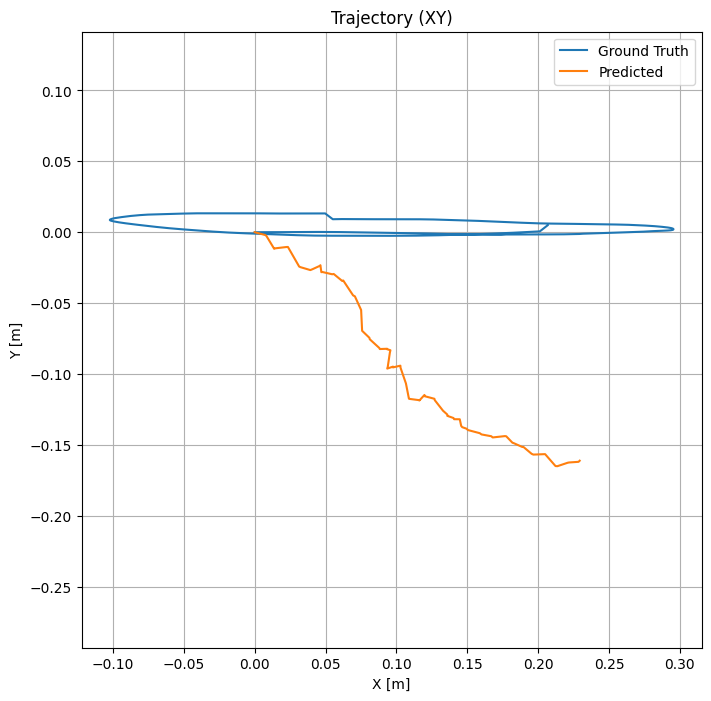

In [74]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

plt.plot(gt_pos[:, 0], gt_pos[:, 1], label="Ground Truth")
plt.plot(pred_positions[:, 0], pred_positions[:, 1], label="Predicted")

plt.axis("equal")
plt.legend()
plt.title("Trajectory (XY)")
plt.xlabel("X [m]")
plt.ylabel("Y [m]")
plt.grid()
plt.show()

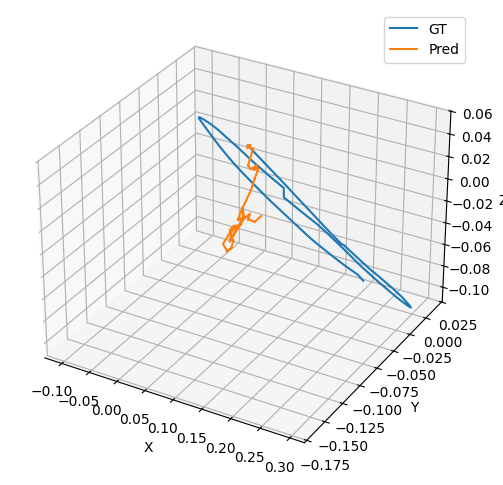

In [75]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(gt_pos[:, 0], gt_pos[:, 1], gt_pos[:, 2], label="GT")
ax.plot(pred_positions[:, 0], pred_positions[:, 1], pred_positions[:, 2], label="Pred")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.show()